# 18 Sep

## distribution of source organism from coconut


In [6]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('/home/school/masters/Scripts/coconut_full/coconut_plants/checklist_matched_organisms.tsv', sep='\t', low_memory=False)

types = df['kingdom'].unique()
types = types.tolist()

for k in range(len(types)): 
    print(str(k) + ') ' + str(types[k]))

0) Plantae
1) Fungi
2) Animalia
3) nan
4) Bacillati
5) Methanobacteriati
6) Chromista
7) Pseudomonadati
8) Protozoa
9) Thermotogati
10) Thermoproteati


In [ ]:
import pandas as pd

df = pd.read_csv('/home/school/masters/Scripts/coconut_full/coconut_plants/checklist_matched_organisms.tsv', sep='\t', low_memory=False)

nums = df['kingdom'].value_counts(dropna=False)


kingdom
Plantae              937333
Fungi                116381
Animalia             105552
Bacillati             55948
NaN                   25285
Pseudomonadati        13485
Chromista             10630
Protozoa               1724
Methanobacteriati       504
Thermotogati            133
Thermoproteati          113
Name: count, dtype: int64


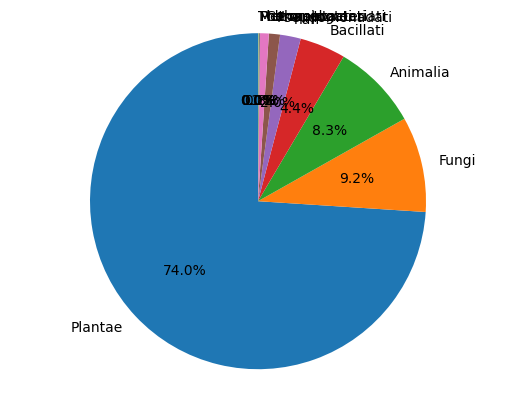

In [12]:
import matplotlib.pyplot as plt


plt.pie(nums, labels=nums.index, autopct='%1.1f%%', startangle=90)
plt.axis('equal')
plt.show()

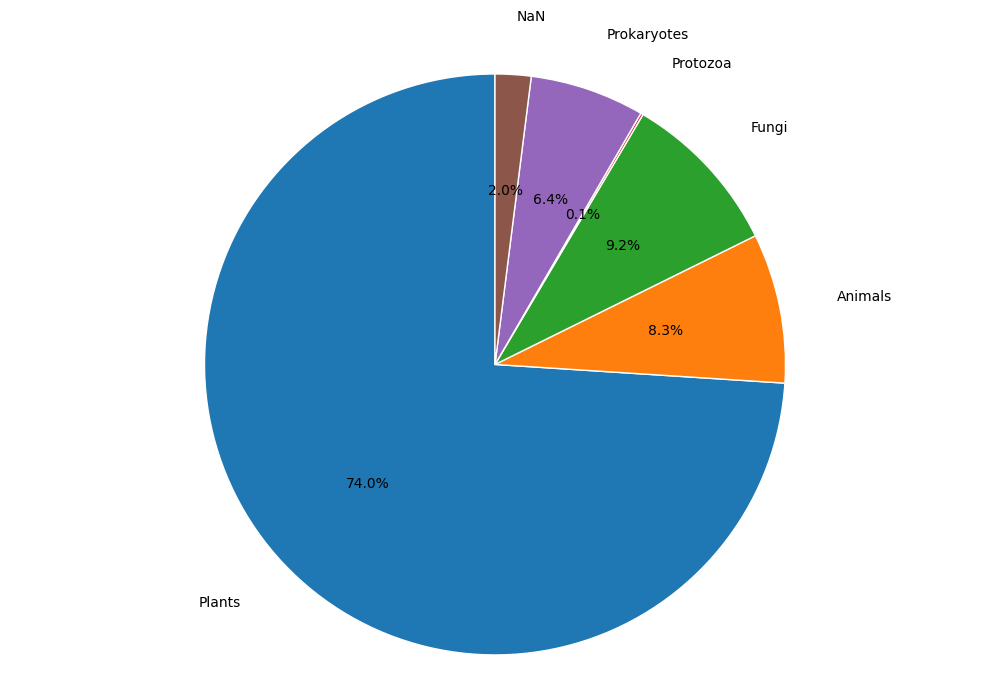

In [26]:
import matplotlib.pyplot as plt

prokaryotes = nums.get('Bacillati',0) + nums.get('Chromista',0) + nums.get('Methanobacteriati',0) + nums.get('Pseudomonadati',0) + nums.get('Thermotogati',0) + nums.get('Thermoproteati',0)

plants = nums.get('Plantae',0)
animals = nums.get('Animalia',0)
fungi = nums.get('Fungi',0)
protozoa = nums.get('Protozoa',0)
nan = df['kingdom'].isna().sum()

values = [plants, animals, fungi, protozoa, prokaryotes, nan]
labels = ['Plants', 'Animals', 'Fungi', 'Protozoa', 'Prokaryotes', 'NaN']

plt.figure(figsize=(10, 7))

plt.pie(
    values,
    labels=labels,
    autopct='%1.1f%%',
    startangle=90,
    labeldistance=1.20,
    pctdistance=0.60,
    textprops={'fontsize': 10},
    wedgeprops={'edgecolor': 'white', 'linewidth': 1}
)

plt.axis('equal')
plt.tight_layout()
plt.show()

## checking how many compounds are made by what organism

Total: 359001
Plant compounds: 175364
Animal compounds: 52930
Fungi compounds: 53262
Protozoa compounds: 1464
Prokaryotes compounds: 50696
NaN compounds: 15984


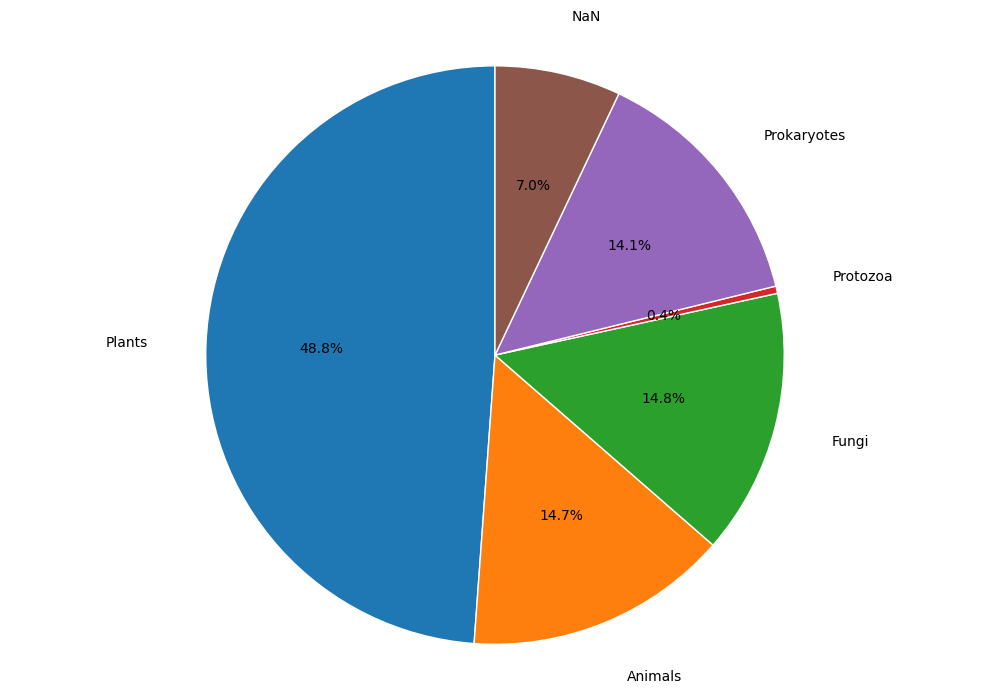

In [30]:
df = pd.read_csv('/home/school/masters/Scripts/coconut_full/coconut_plants/checklist_matched_organisms.tsv', sep='\t', low_memory=False)

nums = df['kingdom'].value_counts(dropna=False)

categories = nums.index.tolist()

plant_compounds = df.loc[df['kingdom'].eq('Plantae')].drop_duplicates(subset='original_coconut_id').shape[0]
animal_compounds = df.loc[df['kingdom'].eq('Animalia')].drop_duplicates(subset='original_coconut_id').shape[0]
fungi_compounds = df.loc[df['kingdom'].eq('Fungi')].drop_duplicates(subset='original_coconut_id').shape[0]
protozoa_compounds = df.loc[df['kingdom'].eq('Protozoa')].drop_duplicates(subset='original_coconut_id').shape[0]
bacillati_compounds = df.loc[df['kingdom'].eq('Bacillati')].drop_duplicates(subset='original_coconut_id').shape[0]
chromista_compounds = df.loc[df['kingdom'].eq('Chromista')].drop_duplicates(subset='original_coconut_id').shape[0]
methanobacteriati_compounds = df.loc[df['kingdom'].eq('Methanobacteriati')].drop_duplicates(subset='original_coconut_id').shape[0]
pseudomonadati_compounds = df.loc[df['kingdom'].eq('Pseudomonadati')].drop_duplicates(subset='original_coconut_id').shape[0]
thermotogati_compounds = df.loc[df['kingdom'].eq('Thermotogati')].drop_duplicates(subset='original_coconut_id').shape[0]
thermoproteati_compounds = df.loc[df['kingdom'].eq('Thermoproteati')].drop_duplicates(subset='original_coconut_id').shape[0]
nan_compounds = df.loc[df['kingdom'].isna()].drop_duplicates(subset='original_coconut_id').shape[0]

prokaryotes = bacillati_compounds + chromista_compounds + methanobacteriati_compounds + pseudomonadati_compounds + thermotogati_compounds + thermoproteati_compounds

values = [plant_compounds, animal_compounds, fungi_compounds, protozoa_compounds, prokaryotes, nan]
labels = ['Plants', 'Animals', 'Fungi', 'Protozoa', 'Prokaryotes', 'NaN']

total = sum(values)
print(f'Total: {total}')
print(f'Plant compounds: {plant_compounds}')
print(f'Animal compounds: {animal_compounds}')
print(f'Fungi compounds: {fungi_compounds}')
print(f'Protozoa compounds: {protozoa_compounds}')
print(f'Prokaryotes compounds: {prokaryotes}')
print(f'NaN compounds: {nan_compounds}')

plt.figure(figsize=(10, 7))

plt.pie(
    values,
    labels=labels,
    autopct='%1.1f%%',
    startangle=90,
    labeldistance=1.20,
    pctdistance=0.60,
    textprops={'fontsize': 10},
    wedgeprops={'edgecolor': 'white', 'linewidth': 1}
)

plt.axis('equal')
plt.tight_layout()
plt.show()


Total: 748143
Plantae + Fungi compounds: 208280
Animalia + Fungi compounds: 91874
Plantae + Animalia compounds: 207733
Plantae + Animalia + Fungi compounds: 240256


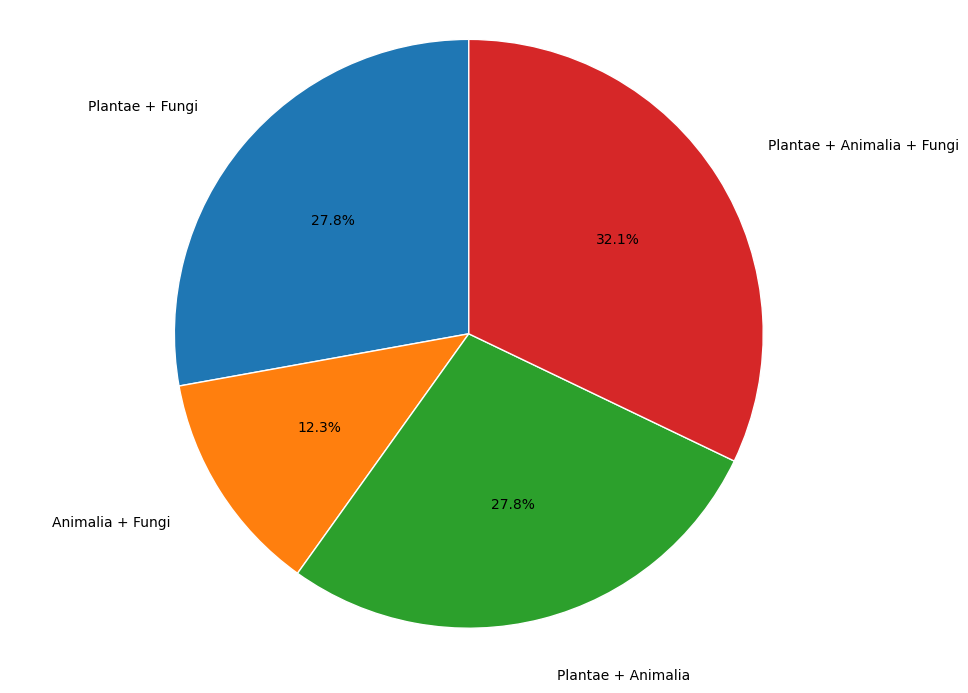

In [ ]:
#####
# this is wrong because it uses plant or fungi not plant and fungi 
# plant_fungi = df.loc[df['kingdom'].isin(['Plantae', 'Fungi'])].drop_duplicates(subset='original_coconut_id').shape[0]
animal_fungi = df.loc[df['kingdom'].isin(['Animalia', 'Fungi'])].drop_duplicates(subset='original_coconut_id').shape[0]
plant_animal = df.loc[df['kingdom'].isin(['Plantae', 'Animalia'])].drop_duplicates(subset='original_coconut_id').shape[0]
plant_animal_fungi = df.loc[df['kingdom'].isin(['Plantae', 'Animalia', 'Fungi'])].drop_duplicates(subset='original_coconut_id').shape[0]

values = [plant_fungi, animal_fungi, plant_animal, plant_animal_fungi]
labels = ['Plantae + Fungi', 'Animalia + Fungi', 'Plantae + Animalia', 'Plantae + Animalia + Fungi']

total = sum(values)
print(f'Total: {total}')
print(f'Plantae + Fungi compounds: {plant_fungi}')
print(f'Animalia + Fungi compounds: {animal_fungi}')
print(f'Plantae + Animalia compounds: {plant_animal}')
print(f'Plantae + Animalia + Fungi compounds: {plant_animal_fungi}')

plt.figure(figsize=(10, 7))

plt.pie(
    values,
    labels=labels,
    autopct='%1.1f%%',
    startangle=90,
    labeldistance=1.20,
    pctdistance=0.60,
    textprops={'fontsize': 10},
    wedgeprops={'edgecolor': 'white', 'linewidth': 1}
)

plt.axis('equal')
plt.tight_layout()
plt.show()



In [32]:
plant = df.loc[df['kingdom'].eq('Plantae')].drop_duplicates(subset='original_coconut_id')['original_coconut_id'].tolist()
animal = df.loc[df['kingdom'].eq('Animalia')].drop_duplicates(subset='original_coconut_id')['original_coconut_id'].tolist()
fungi = df.loc[df['kingdom'].eq('Fungi')].drop_duplicates(subset='original_coconut_id')['original_coconut_id'].tolist()
protozoa = df.loc[df['kingdom'].eq('Protozoa')].drop_duplicates(subset='original_coconut_id')['original_coconut_id'].tolist()
bacillati = df.loc[df['kingdom'].eq('Bacillati')].drop_duplicates(subset='original_coconut_id')['original_coconut_id'].tolist()
chromista = df.loc[df['kingdom'].eq('Chromista')].drop_duplicates(subset='original_coconut_id')['original_coconut_id'].tolist()
methanobacteriati = df.loc[df['kingdom'].eq('Methanobacteriati')].drop_duplicates(subset='original_coconut_id')['original_coconut_id'].tolist()
pseudomonadati = df.loc[df['kingdom'].eq('Pseudomonadati')].drop_duplicates(subset='original_coconut_id')['original_coconut_id'].tolist()
thermotogati = df.loc[df['kingdom'].eq('Thermotogati')].drop_duplicates(subset='original_coconut_id')['original_coconut_id'].tolist()
thermoproteati = df.loc[df['kingdom'].eq('Thermoproteati')].drop_duplicates(subset='original_coconut_id')['original_coconut_id'].tolist()
nan = df.loc[df['kingdom'].isna()].drop_duplicates(subset='original_coconut_id')['original_coconut_id'].tolist()

not_plants = animal + fungi + protozoa + bacillati + chromista + methanobacteriati + pseudomonadati + thermotogati + thermoproteati + nan
no_plants = set(not_plants) 

plants_only = [x for x in plant if x not in no_plants]
print(len(plants_only))

141830
